# 05 - Simulated Annealing

Simulated Annealing es una metaheuristica de trayectoria inspirada en el recocido fisico. Comienza con una temperatura alta que permite aceptar movimientos peores y la reduce gradualmente para estabilizarse en buenas soluciones.


## 1. Idea general

En cada iteracion se propone un vecino. Si mejora, se acepta. Si empeora, se acepta con probabilidad:

\[
\exp\left(-\frac{\Delta}{T}\right)
\]

donde `Delta` es el aumento de costo y `T` es la temperatura. Al inicio, `T` alta permite explorar; al final, `T` baja vuelve el metodo mas exigente.


## 2. Codigo base generico

El motor minimiza una funcion de costo. Solo necesita una solucion inicial y una funcion que genere un vecino aleatorio.


In [1]:
import math
import itertools
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


def make_tsp_instance(n=20, seed=42):
    """Crea una instancia reproducible de ciudades en el plano [0, 1] x [0, 1]."""
    rng = np.random.default_rng(seed)
    return rng.random((n, 2))


def distance_matrix(coords):
    """Calcula la matriz de distancias euclidianas entre ciudades."""
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def tour_length(tour, D):
    """Costo total de una ruta cerrada que vuelve al punto inicial."""
    return float(sum(D[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour))))


def plot_tour(coords, tour, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    closed = list(tour) + [tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], marker="o", linewidth=1.8)
    for idx, (x, y) in enumerate(coords):
        ax.text(x + 0.008, y + 0.008, str(idx), fontsize=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")
    return ax


def plot_convergence(history, title, ylabel="Mejor costo", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Iteracion")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return ax


In [2]:
def simulated_annealing(initial, cost, neighbor, T0=1.0, alpha=0.995,
                        max_iter=5000, seed=0):
    """Simulated Annealing generico para minimizacion."""
    rng = np.random.default_rng(seed)
    current = initial.copy() if hasattr(initial, "copy") else initial
    current_cost = cost(current)
    best = current.copy() if hasattr(current, "copy") else current
    best_cost = current_cost
    T = float(T0)
    history = {"best": [best_cost], "current": [current_cost], "temperature": [T], "accepted": []}

    for _ in range(max_iter):
        candidate = neighbor(current, rng)
        candidate_cost = cost(candidate)
        delta = candidate_cost - current_cost
        accept = delta <= 0 or rng.random() < np.exp(-delta / T)

        if accept:
            current = candidate
            current_cost = candidate_cost
            if current_cost < best_cost:
                best = current.copy() if hasattr(current, "copy") else current
                best_cost = current_cost

        history["best"].append(best_cost)
        history["current"].append(current_cost)
        history["temperature"].append(T)
        history["accepted"].append(accept)
        T *= alpha

    return best, best_cost, history


## 3. Ejemplo: TSP con movimientos 2-opt aleatorios

La solucion es una ruta. En cada paso se eligen dos posiciones al azar y se invierte el segmento entre ellas. Ese movimiento puede mejorar o empeorar la ruta, y la temperatura decide si un empeoramiento se acepta.


In [3]:
coords = make_tsp_instance(n=20, seed=42)
D = distance_matrix(coords)
n = len(coords)
initial_tour = np.arange(n)


def tsp_cost(tour):
    return tour_length(tour, D)


def random_two_opt(tour, rng):
    candidate = tour.copy()
    i, j = sorted(rng.choice(len(candidate), size=2, replace=False))
    if i == j:
        return candidate
    candidate[i:j] = candidate[i:j][::-1]
    return candidate

best_tour, best_len, history = simulated_annealing(
    initial_tour, tsp_cost, random_two_opt,
    T0=0.8, alpha=0.997, max_iter=3500, seed=21
)

accepted_rate = np.mean(history["accepted"]) * 100
print(f"Longitud inicial: {tsp_cost(initial_tour):.3f}")
print(f"Mejor longitud SA: {best_len:.3f}")
print(f"Tasa de aceptacion: {accepted_rate:.1f}%")
print(f"Temperatura final: {history['temperature'][-1]:.5f}")


Longitud inicial: 10.296
Mejor longitud SA: 3.429
Tasa de aceptacion: 20.1%
Temperatura final: 0.00002


### Explicacion general del codigo ejemplo

1. `initial_tour` entrega una ruta inicial ordenada.
2. `random_two_opt` genera un vecino invirtiendo un segmento aleatorio.
3. Si el vecino reduce la distancia, se acepta siempre.
4. Si aumenta la distancia, todavia puede aceptarse segun la temperatura.
5. Al multiplicar `T` por `alpha`, la busqueda pasa gradualmente de exploracion a explotacion.


<notebook-cell>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


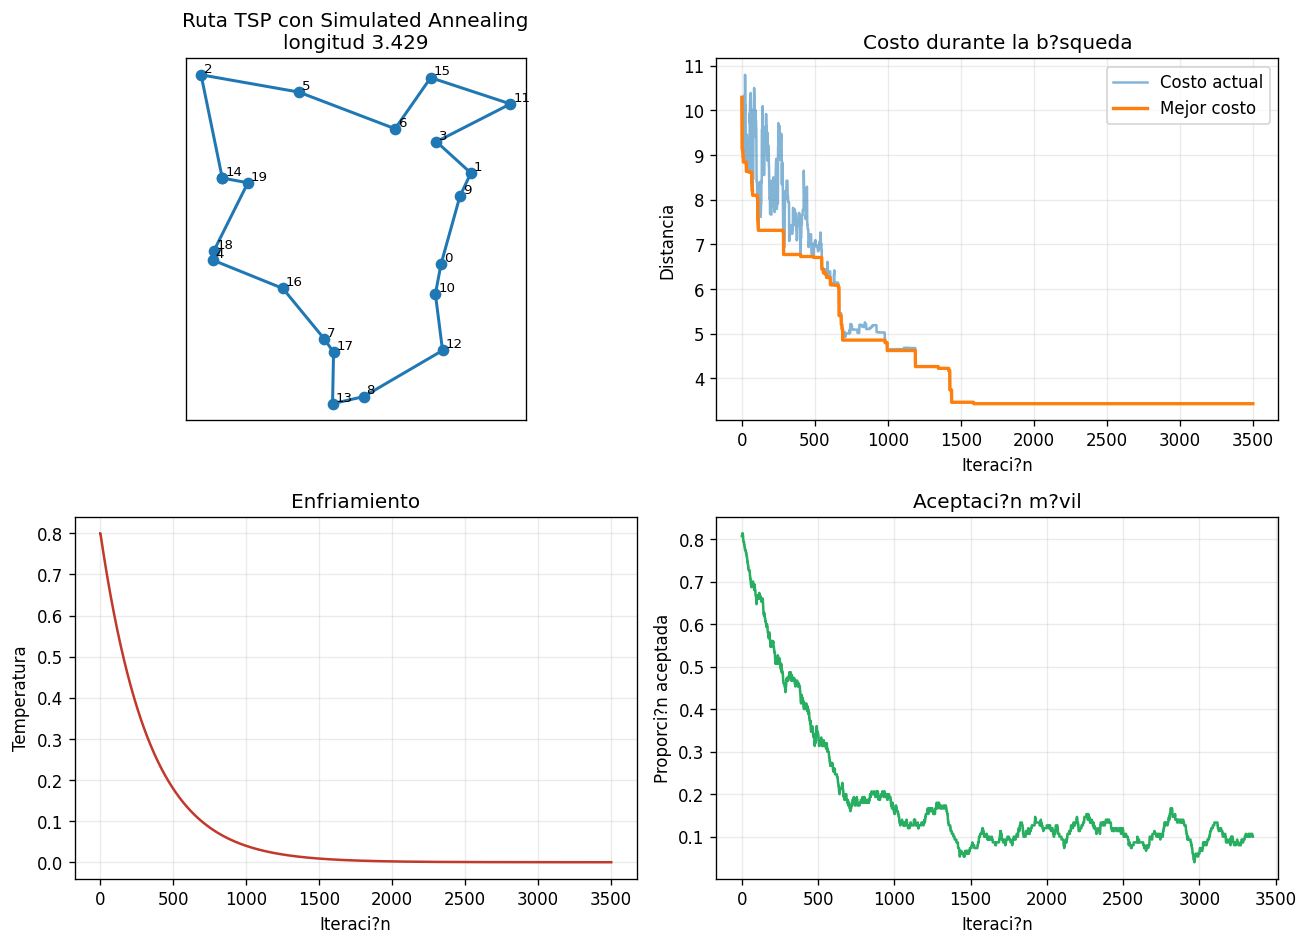

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_tour(coords, best_tour, f"Ruta TSP con Simulated Annealing\nlongitud {best_len:.3f}", ax=axes[0, 0])
axes[0, 1].plot(history["current"], alpha=0.55, label="Costo actual")
axes[0, 1].plot(history["best"], linewidth=2, label="Mejor costo")
axes[0, 1].set_title("Costo durante la busqueda")
axes[0, 1].set_xlabel("Iteracion")
axes[0, 1].set_ylabel("Distancia")
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend()
axes[1, 0].plot(history["temperature"], color="#c0392b")
axes[1, 0].set_title("Enfriamiento")
axes[1, 0].set_xlabel("Iteracion")
axes[1, 0].set_ylabel("Temperatura")
axes[1, 0].grid(alpha=0.25)
window = 150
accepted = np.array(history["accepted"], dtype=float)
rolling = np.convolve(accepted, np.ones(window) / window, mode="valid")
axes[1, 1].plot(rolling, color="#27ae60")
axes[1, 1].set_title("Aceptacion movil")
axes[1, 1].set_xlabel("Iteracion")
axes[1, 1].set_ylabel("Proporcion aceptada")
axes[1, 1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Parametros, ventajas y limites

`T0` debe ser suficientemente alto para aceptar varios movimientos al inicio. `alpha` define la velocidad de enfriamiento: valores cercanos a 1 exploran mas, pero tardan mas. Simulated Annealing es simple y flexible, aunque su desempeno depende mucho de la escala del costo y del diseno del vecindario.
